# Time Series Decomposition: Trend, Seasonality, and Residuals

## Overview

Decomposition separates a time series into interpretable components. It is the first analytical step before modelling, forecasting, or anomaly detection.

| Component | Description |
|---|---|
| **Trend** | Long-term direction — increasing, decreasing, or flat |
| **Seasonality** | Regular periodic fluctuations at a fixed frequency |
| **Remainder** | Residual after removing trend and seasonality — ideally random noise |

**Additive vs. multiplicative:**
- **Additive** (Y = T + S + R): seasonal amplitude is constant — use when swings are the same size regardless of trend level
- **Multiplicative** (Y = T × S × R): seasonal amplitude grows with trend — log-transform then decompose additively

**Methods:**
- **Classical:** Simple moving average trend; fixed seasonal pattern; loses data at ends; not robust
- **STL (Loess-based):** Robust to outliers; seasonal pattern can evolve; no missing values; preferred

---

## Setup

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'forecast' was built under R version 4.4.3"
Warning message:
"package 'patchwork' was built under R version

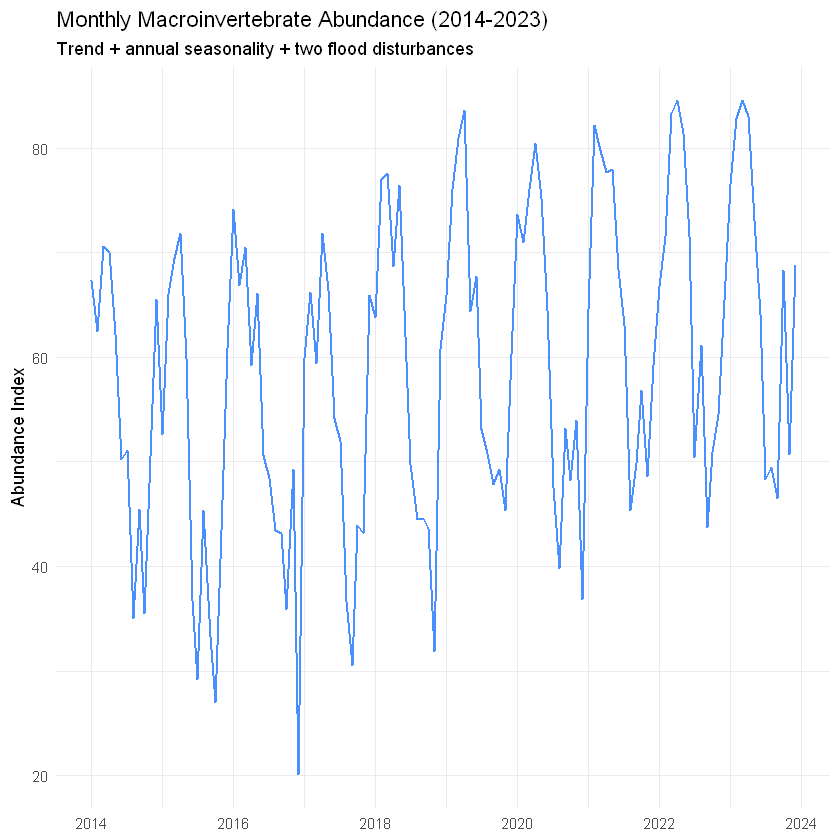

In [1]:
library(tidyverse)
library(ggplot2)
library(forecast)   # stl(), decompose(), mstl()
library(patchwork)

set.seed(42)

# ── Simulate 10 years of monthly ecological data ─────────────────────────────
n      <- 120
months <- seq(as.Date("2014-01-01"), by="month", length.out=n)

trend_c    <- 50 + 0.15 * seq_len(n)
seasonal_c <- 18 * sin(2 * pi * seq_len(n) / 12)
noise_c    <- rnorm(n, 0, 6)
disturb    <- replace(numeric(n), c(36,84), -25)   # flood events

abundance  <- pmax(trend_c + seasonal_c + noise_c + disturb, 5)
eco_ts     <- ts(abundance, start=c(2014,1), frequency=12)

ggplot(tibble(date=months, y=abundance), aes(x=date, y=y)) +
  geom_line(color="#4a8fff", linewidth=0.8) +
  labs(title="Monthly Macroinvertebrate Abundance (2014-2023)",
       subtitle="Trend + annual seasonality + two flood disturbances",
       x=NULL, y="Abundance Index") +
  theme_minimal()

---

## Classical Decomposition

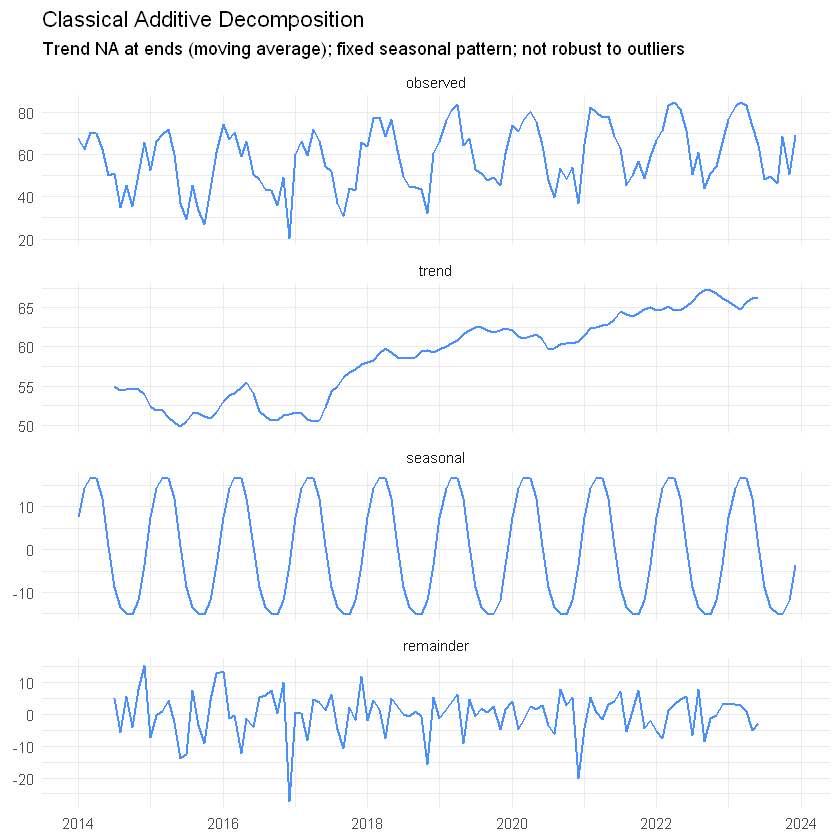

In [2]:
classical <- decompose(eco_ts, type="additive")

# ggplot2 version
tibble(
  date      = months,
  observed  = as.numeric(eco_ts),
  trend     = as.numeric(classical$trend),
  seasonal  = as.numeric(classical$seasonal),
  remainder = as.numeric(classical$random)
) %>%
  pivot_longer(-date, names_to="component", values_to="value") %>%
  mutate(component=factor(component,
    levels=c("observed","trend","seasonal","remainder"))) %>%
  ggplot(aes(x=date, y=value)) +
  geom_line(color="#4a8fff", linewidth=0.7, na.rm=TRUE) +
  facet_wrap(~component, scales="free_y", ncol=1) +
  labs(title="Classical Additive Decomposition",
       subtitle="Trend NA at ends (moving average); fixed seasonal pattern; not robust to outliers",
       x=NULL, y=NULL) +
  theme_minimal()

---

## STL Decomposition (Preferred)

Variance explained: Trend=9.8%  Seasonal=69.1%  Remainder=24.0%
Trend strength: 0.336   Seasonal strength: 0.732  (0=none, 1=strong)


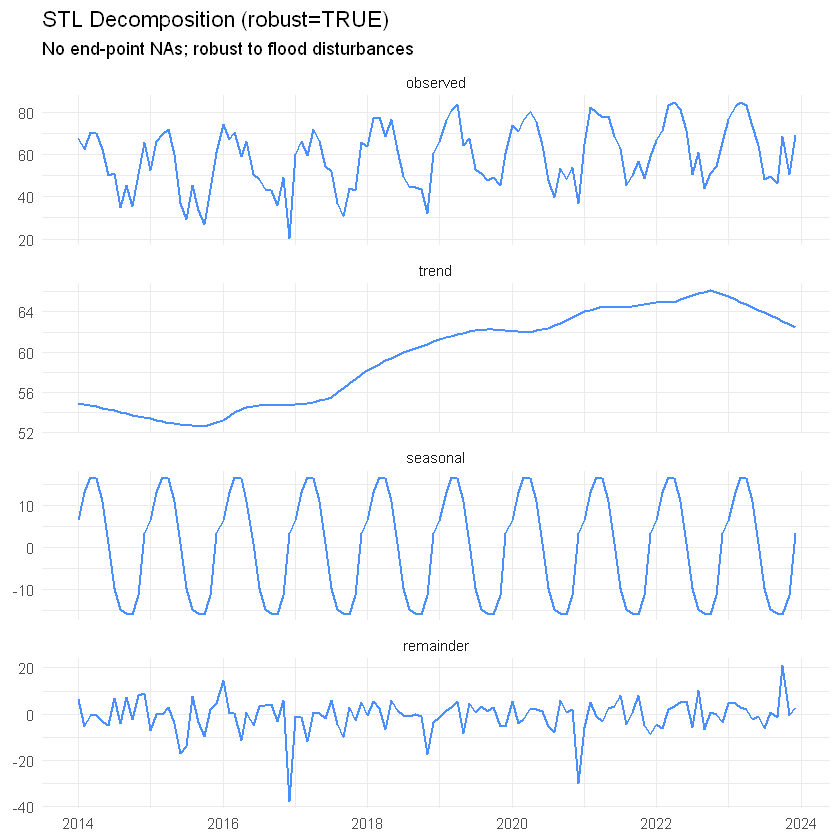

In [3]:
stl_result <- stl(
  eco_ts,
  s.window = "periodic",  # fixed seasonal; use odd integer (e.g. 13) to allow evolution
  t.window = 25,           # trend smoothness; larger = smoother
  robust   = TRUE          # iterative reweighting to down-weight outliers
)

stl_df <- tibble(
  date      = months,
  observed  = abundance,
  trend     = stl_result$time.series[,"trend"],
  seasonal  = stl_result$time.series[,"seasonal"],
  remainder = stl_result$time.series[,"remainder"]
)

# ── Variance explained by each component ─────────────────────────────────────
vt <- var(stl_df$observed)
cat(sprintf("Variance explained: Trend=%.1f%%  Seasonal=%.1f%%  Remainder=%.1f%%\n",
  var(stl_df$trend)/vt*100,
  var(stl_df$seasonal)/vt*100,
  var(stl_df$remainder)/vt*100))

# ── Seasonal strength / trend strength (Hyndman & Athanasopoulos) ─────────────
Ft <- max(0, 1 - var(stl_df$remainder) / var(stl_df$trend    + stl_df$remainder))
Fs <- max(0, 1 - var(stl_df$remainder) / var(stl_df$seasonal + stl_df$remainder))
cat(sprintf("Trend strength: %.3f   Seasonal strength: %.3f  (0=none, 1=strong)\n", Ft, Fs))

# ── STL plot ──────────────────────────────────────────────────────────────────
stl_df %>%
  pivot_longer(-date, names_to="component", values_to="value") %>%
  mutate(component=factor(component,
    levels=c("observed","trend","seasonal","remainder"))) %>%
  ggplot(aes(x=date, y=value)) +
  geom_line(color="#4a8fff", linewidth=0.7) +
  facet_wrap(~component, scales="free_y", ncol=1) +
  labs(title="STL Decomposition (robust=TRUE)",
       subtitle="No end-point NAs; robust to flood disturbances",
       x=NULL, y=NULL) +
  theme_minimal()

---

## Seasonally Adjusted Series

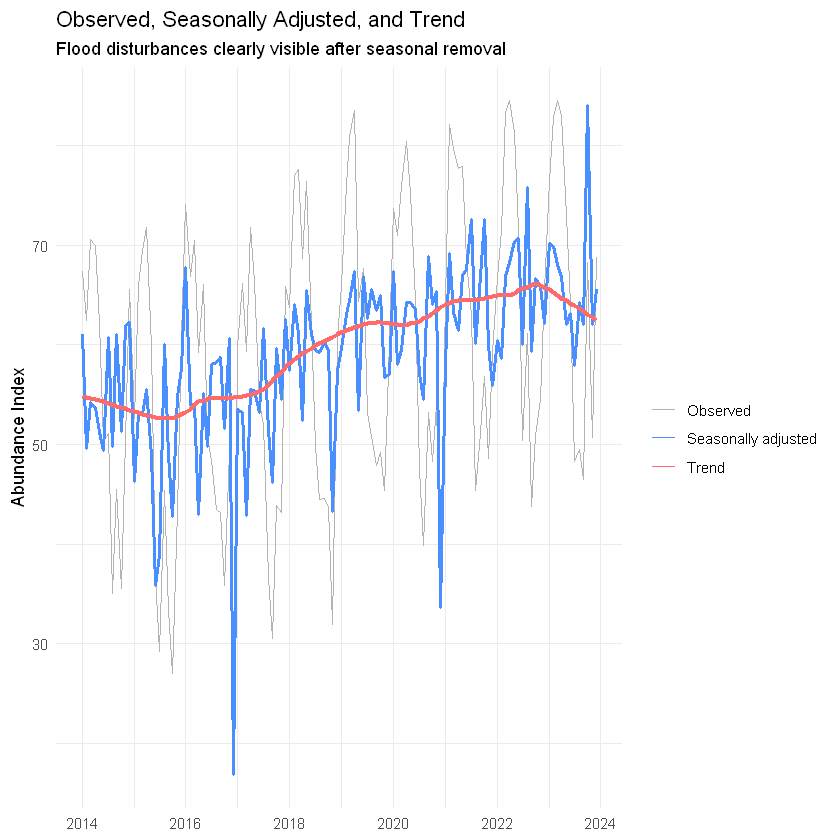

In [4]:
stl_df %>%
  mutate(sa = observed - seasonal) %>%
  pivot_longer(c(observed, sa, trend), names_to="series", values_to="value") %>%
  mutate(series=factor(series, levels=c("observed","sa","trend"))) %>%
  ggplot(aes(x=date, y=value, color=series, linewidth=series)) +
  geom_line() +
  scale_color_manual(
    values=c(observed="gray70", sa="#4a8fff", trend="#ff6b6b"),
    labels=c("Observed","Seasonally adjusted","Trend")
  ) +
  scale_linewidth_manual(values=c(0.5, 0.9, 1.4), guide="none") +
  labs(title="Observed, Seasonally Adjusted, and Trend",
       subtitle="Flood disturbances clearly visible after seasonal removal",
       x=NULL, y="Abundance Index", color=NULL) +
  theme_minimal()

---

## Common Pitfalls

**1. Using classical decomposition for publication**  
Classical decomposition loses data at both ends (moving average), fixes the seasonal pattern identically each year, and is not robust to outliers. STL is preferred in almost all cases.

**2. Using additive decomposition on a multiplicative series**  
If seasonal amplitude grows proportionally with the trend, the series is multiplicative. Log-transform before decomposing additively, or use `decompose(type="multiplicative")`. Check visually: does the size of seasonal swings increase as the trend rises?

**3. Not checking the remainder component**  
Always inspect the remainder. Systematic patterns — autocorrelation, recurring spikes, trends — indicate inadequate decomposition. Check with `acf(stl_df$remainder)` and `Box.test()`.

**4. Over-smoothing the trend with a large `t.window`**  
A very large `t.window` absorbs genuine long-term variation into the trend. A too-small window confounds trend and seasonality. Visualise the decomposition under several values.

**5. Decomposing without enough seasonal cycles**  
STL needs at least two full seasonal cycles. For monthly data, that means at least 24 observations — ideally 36+.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*